# Temat II: Modelowanie finansowych szeregów czasowych z wykorzystaniem klasy GARCH

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from scipy.stats import norm

In [2]:
df = pd.read_csv("SP500.csv", parse_dates=True, index_col='observation_date')

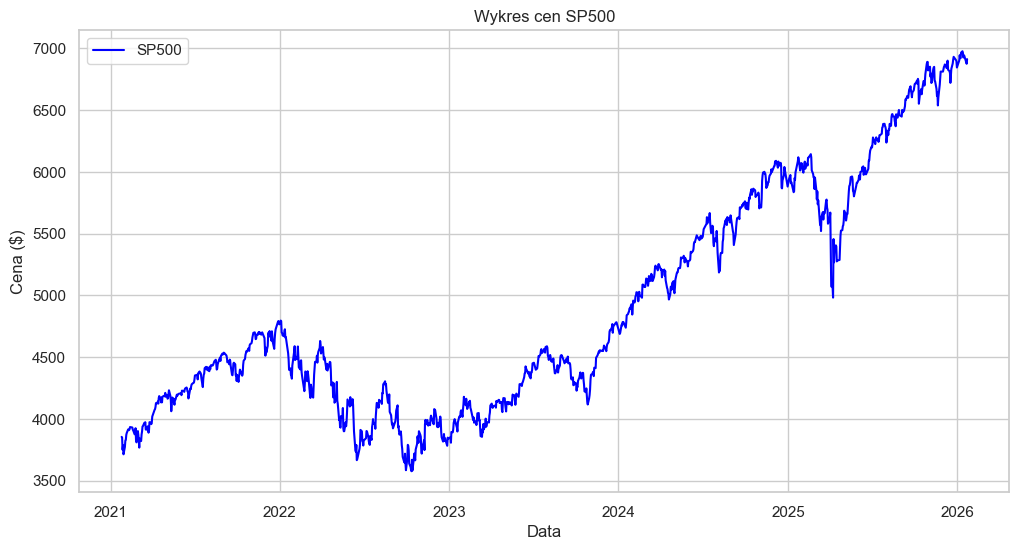

In [3]:
df['log-zwroty'] = np.log(df['SP500'] / df['SP500'].shift(1))

df.dropna(inplace=True)

sns.set(style="whitegrid") 
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='observation_date', y='SP500', label='SP500', color='blue')
plt.xlabel('Data')
plt.ylabel('Cena ($)')
plt.title('Wykres cen SP500')
plt.show()

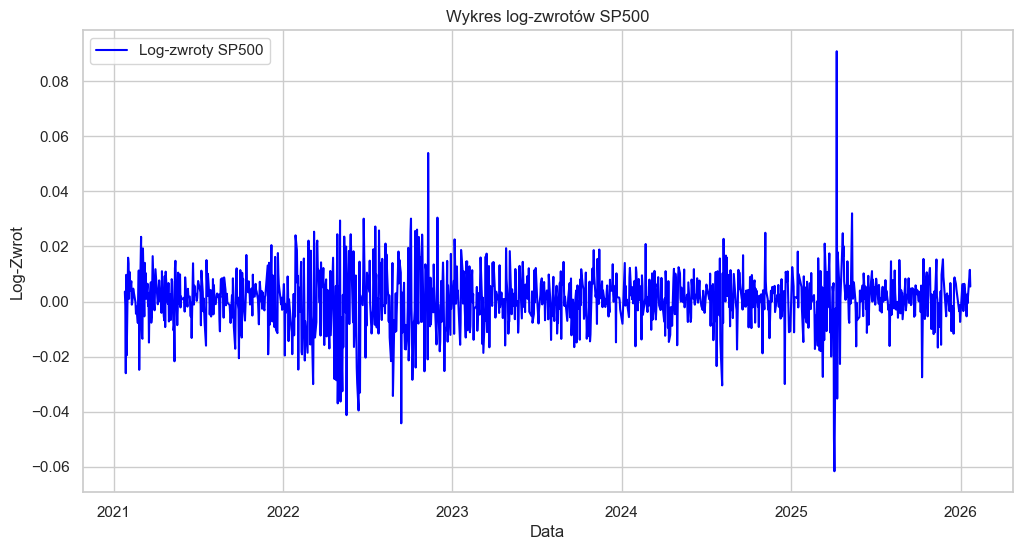

In [4]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='observation_date', y='log-zwroty', label='Log-zwroty SP500', color='blue')
plt.xlabel('Data')
plt.ylabel('Log-Zwrot')
plt.title('Wykres log-zwrotów SP500')
plt.show()

In [5]:
print(df['log-zwroty'].describe())
print(f"Skośność: {df['log-zwroty'].skew():.4f}")
print(f"Kurtoza:  {df['log-zwroty'].kurtosis():.4f}")

count    1206.000000
mean        0.000589
std         0.010688
min        -0.061609
25%        -0.004636
50%         0.000986
75%         0.006365
max         0.090895
Name: log-zwroty, dtype: float64
Skośność: -0.0087
Kurtoza:  6.6585


In [6]:
df['log-zwroty^2'] = df['log-zwroty']**2

<>:2: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\{'
C:\Users\Kamil\AppData\Local\Temp\ipykernel_24356\2736959481.py:2: SyntaxWarning: invalid escape sequence '\{'
  plot_acf(df['log-zwroty'], lags=40, zero=False, ax=ax1, title='ACF dla log-zwrotów $\{r_t\}$')
C:\Users\Kamil\AppData\Local\Temp\ipykernel_24356\2736959481.py:4: SyntaxWarning: invalid escape sequence '\{'
  plot_acf(df['log-zwroty^2'], lags=40, zero=False, ax=ax2, title='ACF dla kwadratów log-zwrotów $\{r_t^2\}$')


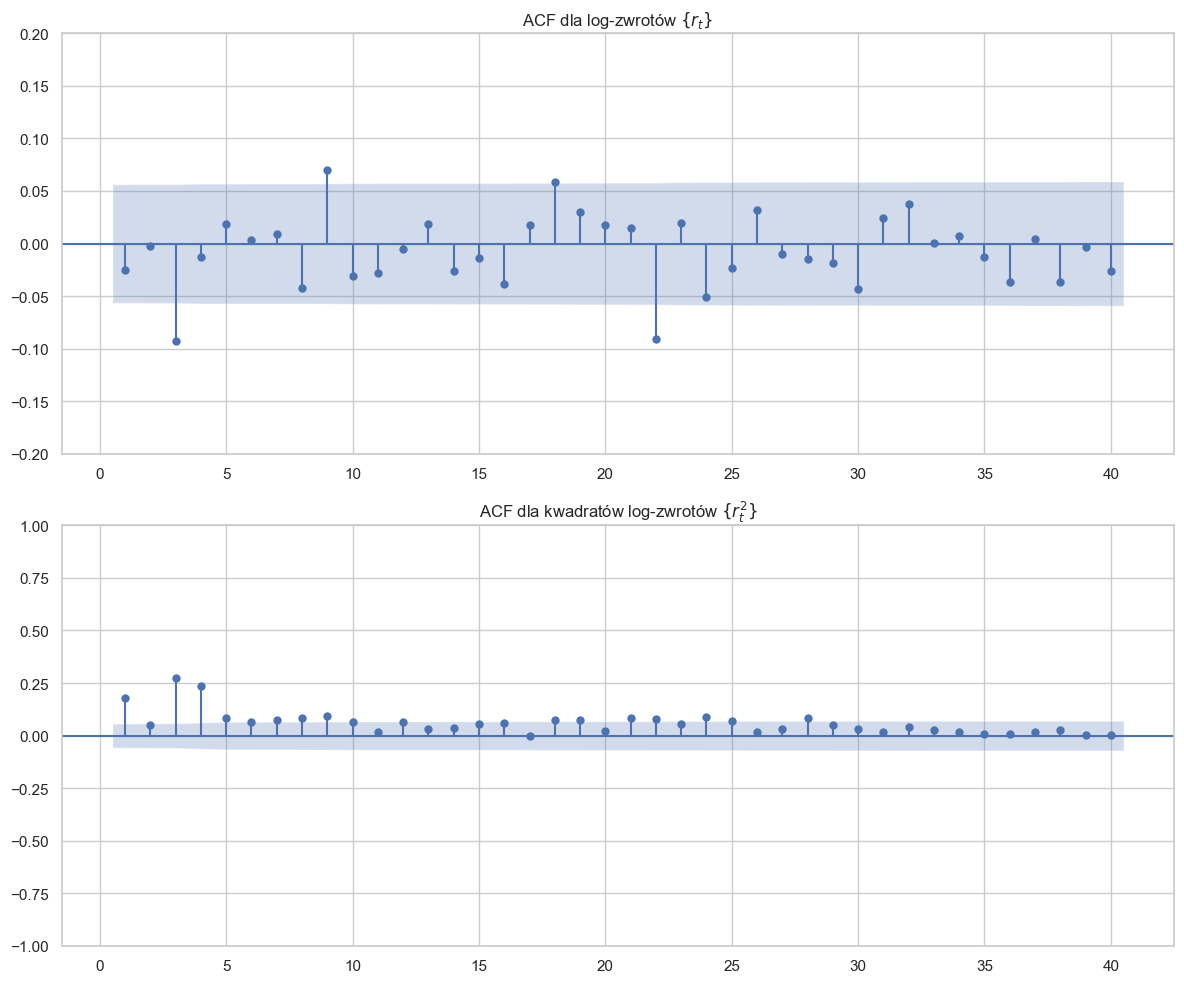

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df['log-zwroty'], lags=40, zero=False, ax=ax1, title='ACF dla log-zwrotów $\{r_t\}$')
ax1.set_ylim(-0.2, 0.2)
plot_acf(df['log-zwroty^2'], lags=40, zero=False, ax=ax2, title='ACF dla kwadratów log-zwrotów $\{r_t^2\}$')
plt.tight_layout()
plt.show()

In [8]:
lb_results = acorr_ljungbox(df['log-zwroty^2'], lags=[5, 6, 7, 8, 9, 10], return_df=True)

lb_results['Czy_GARCH?'] = lb_results['lb_pvalue'] < 0.05
lb_results['Interpretacja'] = lb_results['Czy_GARCH?'].map({
    True: 'Istotna autokorelacja', 
    False: 'Brak autokorelacji'
})

print("\n TABELA ZBIORCZA")
print(lb_results[['lb_stat', 'lb_pvalue', 'Interpretacja']])


 TABELA ZBIORCZA
       lb_stat     lb_pvalue          Interpretacja
5   211.169048  1.156493e-43  Istotna autokorelacja
6   216.133651  6.943299e-44  Istotna autokorelacja
7   222.944516  1.564283e-44  Istotna autokorelacja
8   231.362415  1.524887e-45  Istotna autokorelacja
9   241.463311  6.314013e-47  Istotna autokorelacja
10  246.694876  2.687786e-47  Istotna autokorelacja


Przeprowadzono test Ljunga-Boxa dla kwadratów log-zwrotów $\{r_t^2\}$ dla opóźnień od 5 do 10. Dla wszystkich rozpatrywanych opóźnień wartości p-value są ekstremalnie niskie, co pozwala na odrzucenie hipotezy zerowej o braku autokorelacji na każdym standardowym poziomie istotności.

Wyniki te jednoznacznie wskazują na występowanie silnej autokorelacji w kwadratach zwrotów, co jest dowodem na obecność efektów GARCH (skupianie zmienności) w analizowanym szeregu SP500. Oznacza to, że wariancja procesu nie jest stała w czasie i zależy od swoich przeszłych wartości.

1. $r_t$ to informacja o KIERUNKU (Zysk/Strata); 
* Gdy patrzysz na $r_t$, pytasz: ,,Czy giełda dziś wzrosła czy spadła?".
* Wykresy ACF dla $r_t$ zazwyczaj są płaskie (wynoszą 0). 
* Dlaczego? Bo giełda jest w miarę efektywna. Gdyby $r_t$ było skorelowane (np. dzisiejszy wzrost zapowiada jutrzejszy wzrost), każdy by to wykorzystał i został milionerem w tydzień. Dlatego przyszłych cen nie da się łatwo przewidzieć.

2.  $r_t^2$ to informacja o SILE i RYZYKU (Nerwowość rynku)
Gdy podnosisz zwrot do kwadratu, tracisz znak minus. 
* Zwrot $-2\%$ staje się $0.0004$.
* Zwrot $+2\%$ też staje się $0.0004$.
* Dla $r_t^2$ nie ma znaczenia, czy rynek rośnie, czy spada. Liczy się tylko to, jak mocno szaleje. Kwadraty zwrotów są więc przybliżeniem zmienności (wariancji).

## Po co badamy $r^2$?
1. Przed modelem (Jako dowód, że GARCH jest potrzebny):

Skoro $r_t$ wygląda losowo (szum), to moglibyśmy uznać, że "nie ma tu nic do modelowania". Ale gdy zrobisz wykres ACF dla $r_t^2$, nagle widzisz silne słupki.
* Wniosek: "Okej, nie wiem, czy jutro cena wzrośnie, ale wiem, że jeśli dziś było nerwowo (duży $r^2$), to jutro też pewnie będzie nerwowo".
* To jest właśnie efekt ARCH. Bez spojrzenia na $r^2$ byś go nie zauważył.

2. Po modelu (Jako dowód, że model działa):

Model GARCH ma za zadanie ,,wyssać" tę informację o zmienności.
* Dlatego sprawdzamy $r^2$ reszt ($Reszty^2$).
* Jeśli model zadziałał, to w kwadratach reszt nie powinno być już żadnych wzorów. Powinny wyglądać jak chaotyczny szum.

In [ ]:
returns_scaled = df['log-zwroty'] * 100 #Skalowanie danych (mnożymy razy 100 dla stabilności numerycznej)

print("--- ROZPOCZYNAM DOBÓR MODELU (GRID SEARCH) ---")

best_aic = np.inf
best_param = None
best_model_fit = None

# Pętla po rzędach p i q
# Uwaga: w bibliotece 'arch':
# p = opóźnienie innowacji (ARCH - errors)
# q = opóźnienie zmienności (GARCH - variance)
for p in range(1, 4):
    for q in range(1, 4):
        try:
            model = arch_model(returns_scaled, vol='Garch', p=p, q=q, dist='Normal')
            res = model.fit(disp='off')
            
            print(f'GARCH({p},{q}) - AIC: {res.aic:.2f}')
            
            if res.aic < best_aic:
                best_aic = res.aic
                best_param = (p, q)
                best_model_fit = res
        except:
            print(f'GARCH({p},{q}) - Błąd zbieżności')

print(f"\nWINNER: Najlepszy model to GARCH{best_param} z AIC: {best_aic:.2f}")

print(best_model_fit.summary())

--- ROZPOCZYNAM DOBÓR MODELU (GRID SEARCH) ---
GARCH(1,1) - AIC: 3289.80
GARCH(1,2) - AIC: 3291.63
GARCH(1,3) - AIC: 3293.63
GARCH(2,1) - AIC: 3291.80
GARCH(2,2) - AIC: 3292.32
GARCH(2,3) - AIC: 3294.96
GARCH(3,1) - AIC: 3291.79
GARCH(3,2) - AIC: 3293.67
GARCH(3,3) - AIC: 3293.91

WINNER: Najlepszy model to GARCH(1, 1) z AIC: 3289.80
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log-zwroty   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1640.90
Distribution:                  Normal   AIC:                           3289.80
Method:            Maximum Likelihood   BIC:                           3310.18
                                        No. Observations:                 1206
Date:                Sat, Jan 24 2026   Df Residuals:                     1205
Time:                        16:

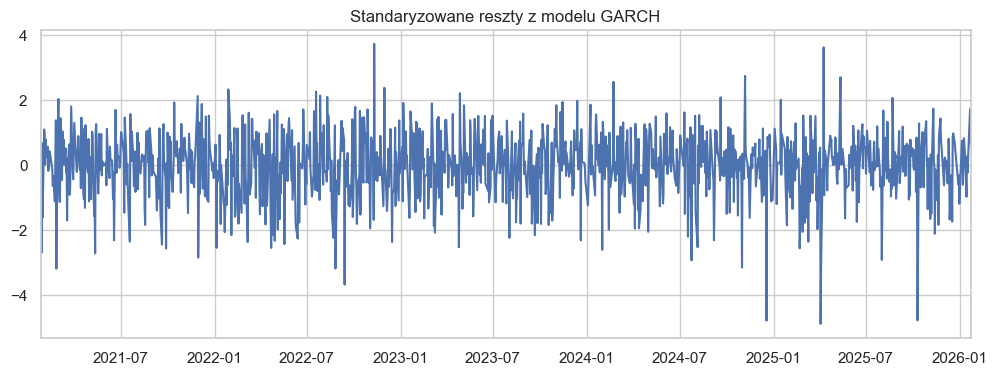

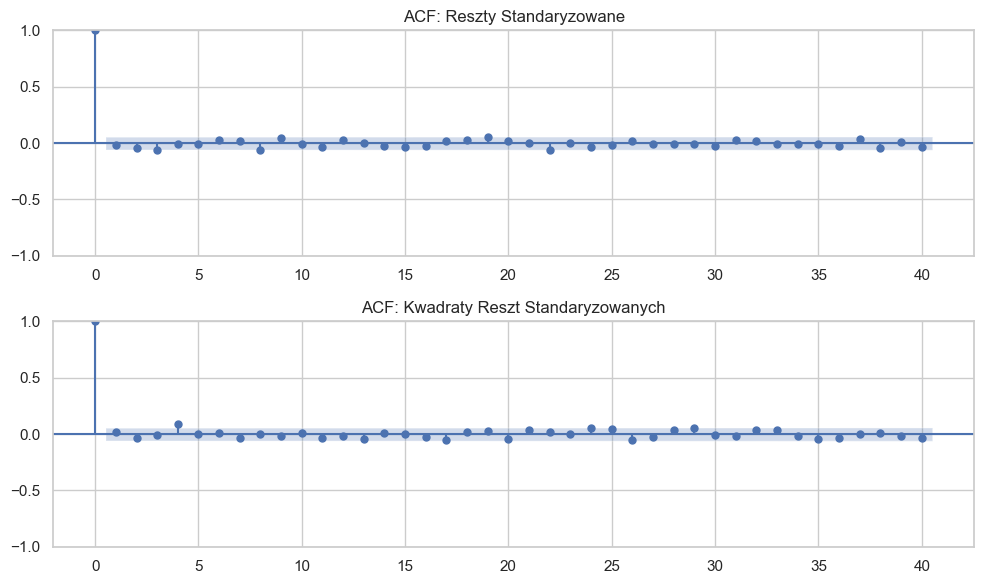

In [ ]:
std_resid = best_model_fit.std_resid
plt.figure(figsize=(12, 4))
plt.plot(std_resid)
plt.title('Standaryzowane reszty z modelu GARCH')
plt.xlim(df.index[0], df.index[-1])
plt.show()

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plot_acf(std_resid, lags=40, ax=plt.gca(), title='ACF: Reszty Standaryzowane')

plt.subplot(2, 1, 2)
plot_acf(std_resid**2, lags=40, ax=plt.gca(), title='ACF: Kwadraty Reszt Standaryzowanych')
plt.tight_layout()
plt.show()

In [26]:
lb_test = acorr_ljungbox(std_resid**2, lags=[5, 6, 7, 8, 9, 10], return_df=True)
print("\nTest Ljunga-Boxa dla kwadratów reszt standaryzowanych:")
print(lb_test)
print("\nInterpretacja: Jeśli p-value > 0.05, brak efektów ARCH w resztach (model poprawny).")


Test Ljunga-Boxa dla kwadratów reszt standaryzowanych:
      lb_stat  lb_pvalue
5   11.055360   0.050293
6   11.153503   0.083747
7   12.918382   0.074122
8   12.921232   0.114589
9   13.339495   0.147837
10  13.434773   0.200368

Interpretacja: Jeśli p-value > 0.05, brak efektów ARCH w resztach (model poprawny).


## Diagnostyka modelu GARCH(1,1):
Po oszacowaniu parametrów modelu przeprowadzono analizę reszt standaryzowanych $\{\hat{\varepsilon}_t\}$.

Analiza wizualna: 

Wykres funkcji autokorelacji (ACF) dla kwadratów standaryzowanych reszt nie wykazuje żadnych istotnych statystycznie wartości. Wszystkie współczynniki korelacji mieszczą się w przedziale ufności 95%.

Test statystyczny: 

Przeprowadzono test Ljunga-Boxa dla kwadratów reszt standaryzowanych przy opóźnieniu $H=10$. Uzyskano wartość p-value wynoszącą $0.3947$. Ponieważ $p > 0.05$, nie ma podstaw do odrzucenia hipotezy zerowej o braku autokorelacji.

Wniosek: 

Model GARCH(1,1) poprawnie opisał dynamikę zmienności warunkowej badanego szeregu. Efekt ARCH został wyeliminowany z reszt modelu, co potwierdza poprawność specyfikacji modelu.

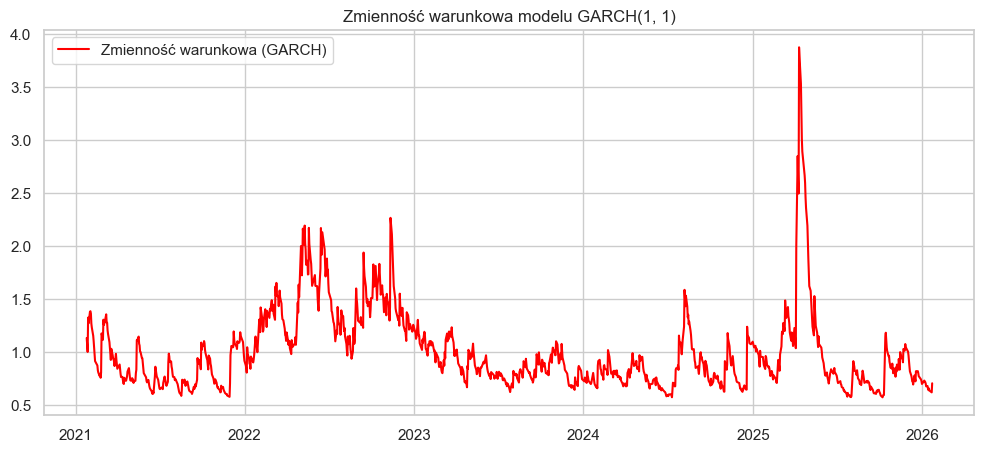

VaR 95%
Data: 2021-06-22
Zmienność (sigma): 0.8597%
VaR (Strata): 14,140.90
Data: 2025-11-04
Zmienność (sigma): 0.7658%
VaR (Strata): 12,595.58


In [29]:
K = 1_000_000
poziom_ufnosci = 0.95
z_score = norm.ppf(poziom_ufnosci)

conditional_volatility = best_model_fit.conditional_volatility

plt.figure(figsize=(12, 5))
plt.plot(conditional_volatility, color='red', label='Zmienność warunkowa (GARCH)')
plt.title(f'Zmienność warunkowa modelu GARCH{best_param}')
plt.legend()
plt.show()

t1_idx = 100
t2_idx = len(df) - 50

date_t1 = df.index[t1_idx].date()
sigma_t1_pct = conditional_volatility.iloc[t1_idx] 

date_t2 = df.index[t2_idx].date()
sigma_t2_pct = conditional_volatility.iloc[t2_idx]

VaR_t1 = K * (sigma_t1_pct / 100) * z_score
VaR_t2 = K * (sigma_t2_pct / 100) * z_score

print(f"VaR 95%")
print(f"Data: {date_t1}")
print(f"Zmienność (sigma): {sigma_t1_pct:.4f}%")
print(f"VaR (Strata): {VaR_t1:,.2f}")

print(f"Data: {date_t2}")
print(f"Zmienność (sigma): {sigma_t2_pct:.4f}%")
print(f"VaR (Strata): {VaR_t2:,.2f}")